In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch

In [26]:
df = pd.read_csv('./data/airline-passengers.csv')
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


time_series.shape = (144, 1)


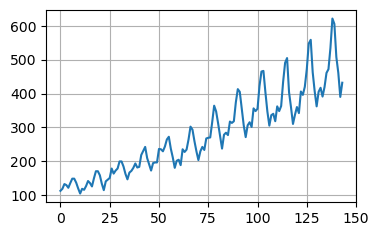

In [27]:
time_series = df[["Passengers"]].values.astype(np.float32)
print(f"time_series.shape = {time_series.shape}")
plt.figure(figsize=(4, 2.5))
plt.plot(time_series)
plt.grid(True)
plt.show()

In [28]:
# train-test split for time series
train_size = int(time_series.shape[0] * 2/3)
test_size = time_series.shape[0] - train_size
train, test = time_series[:train_size], time_series[train_size:]
print(f"train.shape = {train.shape}")
print(f"test.shape = {test.shape}")

train.shape = (96, 1)
test.shape = (48, 1)


In [29]:
def create_dataset(dataset, lookback):
    """
    Transform a time series into a prediction dataset
    Args:
        dataset: a numpy array of time series, first dimension is the time steps
        lookback: size of window for prediction
    """
    X, y = [], []
    for i in range(len(dataset) - lookback):
        feature = dataset[i:i+lookback]
        target = dataset[i+1:i+lookback+1]
        X.append(feature)
        y.append(target)

    return torch.from_numpy(np.array(X)), torch.from_numpy(np.array(y))

In [30]:
lookback = 20
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(f"X_train.shape = {X_train.shape}")
print(f"y_trains.shape = {y_train.shape}")
print(f"X_test.shape = {X_test.shape}")
print(f"y_test.shape = {y_test.shape}")

X_train.shape = torch.Size([76, 20, 1])
y_trains.shape = torch.Size([76, 20, 1])
X_test.shape = torch.Size([28, 20, 1])
y_test.shape = torch.Size([28, 20, 1])


In [31]:
import torch.nn as nn

In [32]:
class AirlineModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=1, batch_first=True)
        self.linear = nn.Linear(50, 1)

    def forward(self, input):
        x, _ = self.lstm(input)
        
        x = self.linear(x)
        return x

In [33]:
model = AirlineModel()
X_batch = torch.rand(size=(12, 5, 1))
y_batch = model(X_batch)

print(f"X_batch.shape = {X_batch.shape}")
print(f"y_batch.shape = {y_batch.shape}")

X_batch.shape = torch.Size([12, 5, 1])
y_batch.shape = torch.Size([12, 5, 1])


In [34]:
import torch.optim as optim
import torch.utils.data as data

model = AirlineModel()
optimizer = optim.Adam(model.parameters())
dataloader = data.DataLoader(data.TensorDataset(X_train, y_train), shuffle=True, batch_size=12)

criterion = nn.MSELoss()

In [35]:
n_epochs = 2000
for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in dataloader:
        
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

    # Validiation
    if epoch % 100 != 0:
        continue

    model.eval()
    with torch.no_grad():
        y_pred = model(X_train)
        train_rmse = np.sqrt(criterion(y_pred, y_train))
        y_pred = model(X_test)
        test_rmse = np.sqrt(criterion(y_pred, y_test))

    print(f"Epoch {epoch}: train RMSE = {train_rmse:5.4f} -- test RMSE = {test_rmse:5.4f}")

Epoch 0: train RMSE = 220.3327 -- test RMSE = 417.7656
Epoch 100: train RMSE = 192.7702 -- test RMSE = 389.4258
Epoch 200: train RMSE = 169.9856 -- test RMSE = 365.7343
Epoch 300: train RMSE = 149.5843 -- test RMSE = 344.1869
Epoch 400: train RMSE = 130.7572 -- test RMSE = 323.8488
Epoch 500: train RMSE = 113.5575 -- test RMSE = 304.6267
Epoch 600: train RMSE = 98.1797 -- test RMSE = 286.5109
Epoch 700: train RMSE = 85.0391 -- test RMSE = 269.6791
Epoch 800: train RMSE = 73.5303 -- test RMSE = 253.6779
Epoch 900: train RMSE = 58.3192 -- test RMSE = 231.5020
Epoch 1000: train RMSE = 48.7743 -- test RMSE = 214.4946
Epoch 1100: train RMSE = 41.1226 -- test RMSE = 198.9781
Epoch 1200: train RMSE = 35.4724 -- test RMSE = 185.5785
Epoch 1300: train RMSE = 31.1137 -- test RMSE = 173.4666
Epoch 1400: train RMSE = 27.1079 -- test RMSE = 161.1032
Epoch 1500: train RMSE = 23.7723 -- test RMSE = 149.8374
Epoch 1600: train RMSE = 20.8840 -- test RMSE = 139.6686
Epoch 1700: train RMSE = 18.5180 -- t

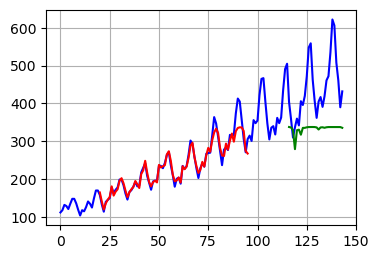

In [36]:
with torch.no_grad():
    # shift train predictions for plotting
    train_plot = np.ones_like(time_series) * np.nan
    y_pred = model(X_train)
    y_pred = y_pred[:, -1, :]
    train_plot[lookback:train_size] = model(X_train)[:, -1, :]
    # shift test prediction for plotting
    test_plot = np.ones_like(time_series) * np.nan
    test_plot[train_size+lookback : len(time_series)] = model(X_test)[:,-1,:]

# plot
plt.figure(figsize=(4, 2.8))
plt.plot(time_series, 'b-')
plt.plot(train_plot, 'r-')
plt.plot(test_plot, 'g-')
plt.grid(True)
plt.show()